## Simple Linear Regression

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split

In [3]:
df = pd.read_csv('../0-Dataset/height-weight.csv')
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


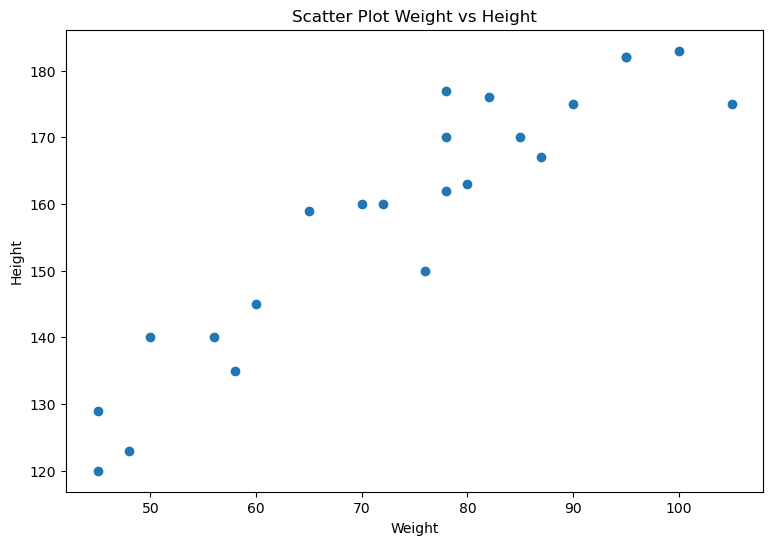

In [4]:
## Scatter Plot
plt.figure(figsize=(9,6))
plt.title('Scatter Plot Weight vs Height')
plt.scatter(df['Weight'], df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')
plt.show()
plt.close()

In [5]:
## Correlation
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


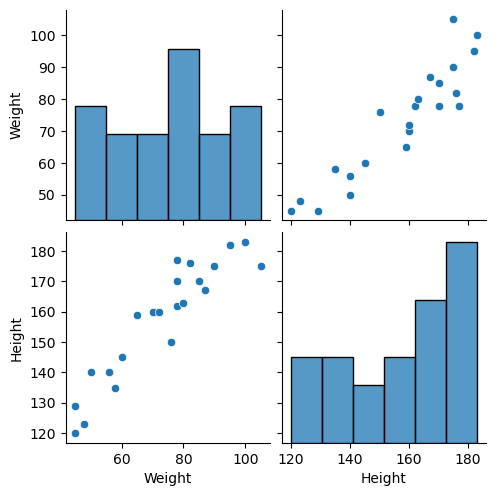

In [6]:
## Seaborn visualization
sns.pairplot(df)

In [7]:
## Independent and Dependent features

X = df[['Weight']] ## independent features should be data frame of 2 dimensional array
y = df['Height']  ## This variable is in series form or 1 D array

In [8]:
## Train test split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 42)

In [9]:
X.shape, y.shape, X_test.shape, X_train.shape, y_test.shape, y_train.shape

((23, 1), (23,), (6, 1), (17, 1), (6,), (17,))

In [10]:
## Standardization

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()


##### Important things about the fit_transform and transform
- Why we use the fit_transform with the training dataset and transform with the test dataset?

- Using the fit_transform with the training dataset it using the Z-score to transform the values where the **mean of the X_train dataset is 0 and the standard deviation of the X_test data is 1**

- When we are going to use our X_train then in this case we are using the **transform** method in place of **fit_transform** because we are using the same value of mean and standard deviation which is calculated in the X_train values it is prevent the data leak.

- If we use the **fit_transform** in X_test dataset then we have give the information of our data in the testing phase and we are not wanted these things in case of testing the data

In [11]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [13]:
X_test

array([[ 0.33497168],
       [ 0.33497168],
       [-1.6641678 ],
       [ 1.36483141],
       [-0.45256812],
       [ 1.97063125]])

## Apply Simple Linear Regression

In [14]:
from sklearn.linear_model import LinearRegression

In [15]:
regression = LinearRegression()

In [17]:
regression.fit(X_train, y_train)

LinearRegression()

In [ ]:
print("Coefficient or Slope:", regression.coef_)
print("Intercept:", regression.intercept_)

## Here slope means if you move the one unit in X axis the movement in Y axis is 17.29 units

## Intercept means if your x value is 0 then the value of y is 156.47


Coefficient or Slope: [17.2982057]
Intercept: 156.47058823529412


#### Plot training data and best fit line

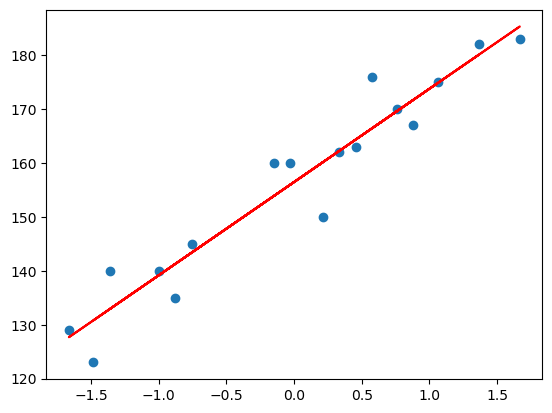

In [25]:
plt.scatter(X_train, y_train)
plt.plot(X_train, regression.predict(X_train), color = 'red')

#### Prediction for test data
1. prediction height output = intercept + coef_(Weight)
2. y_pred_test = 156.740 + 17.29(X_test)

In [27]:
y_pred= regression.predict(X_test)
y_pred

array([162.26499721, 162.26499721, 127.68347133, 180.07972266,
       148.64197186, 190.55897293])

#### Performance matrics